# Comparing predicted protein abundances vs. measured values

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from collections import defaultdict


from PAModelpy.utils.pam_generation import set_up_pam

# Get the current working directory
current_directory = os.getcwd()
# If required go to repository root
if os.path.split(current_directory)[1] != 'PAM_Parametrization':
    # Go up two levels
    parent_directory = os.path.dirname(os.path.dirname(current_directory))
    # Change the directory to the parent directory
    os.chdir(parent_directory)
    
from Modules.utils.pamparametrizer_analysis import (get_results_from_simulations_fixed_mu, 
                                                    parse_enzyme_complex_id,
                                                    convert_peptide_to_enzyme_concentrations
                                                   )
from Modules.utils.pam_generation import create_pamodel_from_diagnostics_file


Loading PAModelpy modules version 0.0.4.6
Set parameter Username
Academic license - for non-commercial use only - expires 2025-03-06


In [2]:
NUM_ALT_MODELS =10
PAM_KCAT_FILES = [os.path.join('Results', '3_analysis', 'parameter_files',
                                   f'proteinAllocationModel_EnzymaticData_iML1515_{file_nmbr}.xlsx') for file_nmbr in
                      range(1, NUM_ALT_MODELS+1)]
BEST_INDIV_RESULT_FILES = [os.path.join('Results','2_parametrization','diagnostics',
                                     f'pam_parametrizer_diagnostics_{i}.xlsx') for i in range(1,NUM_ALT_MODELS+1)]
ORI_PAM_KCAT_FILE = os.path.join('Results', '1_preprocessing',
                                 'proteinAllocationModel_iML1515_EnzymaticData_250214.xlsx')
ECOLI_PROTEOME_DATA_PATH = os.path.join('Data', 'Ecoli_phenotypes', 'proteome_data_extract_schmidt2016.xlsx')
ECOLI_MODEL_FILE_PATH = os.path.join('Models', 'iML1515.xml')
UNIPROT_INFO_FILE = os.path.join('Data', 'Databases', 'uniprotkb_ecolik12_240726.xlsx')

#average values from Bakken and Olsen (1984); https://pubmed.ncbi.nlm.nih.gov/16346263/
buoyant_volume = 1.09 #g_wetcell/cm^3
dryweight_per_wetweight = 0.3
DRYWEIGHT_PER_LITER = buoyant_volume*1e3*dryweight_per_wetweight #1e3 to convert cm^-3 to dm^-3

locustag_regex =r'\b([b|s]\d{4})\b'

## 1. Get the protein concentrations from the models

In [3]:
substrate_rates = [0.67, 0.5, 0.35]
pam =  set_up_pam(ORI_PAM_KCAT_FILE, ECOLI_MODEL_FILE_PATH, sensitivity=False)
enzymes = [enz.id for enz in pam.enzyme_variables if enz._model is not None]

proteomics_results={'GotEnzymes': get_results_from_simulations_fixed_mu(pamodel=pam,
                                                                           growth_rates = substrate_rates,
                                                                           proteins_to_save = enzymes,
                                                                          method_ids = ['Batch', 'mu_5', 'mu_35']
                                                                          )['proteins']}

for file, label in zip(BEST_INDIV_RESULT_FILES,
                       [f'Alternative {i}' for i in range(1,len(PAM_KCAT_FILES)+1)]
                      ):
    print('\n')
    print(label)
    model = create_pamodel_from_diagnostics_file(file,
                                          pam.copy(copy_with_pickle=True))
#     model = set_up_pam(file, ECOLI_MODEL_FILE_PATH, sensitivity=False)
    enzymes = [enz.id for enz in model.enzyme_variables if enz._model is not None]
    proteomics_results[label] = get_results_from_simulations_fixed_mu(pamodel=model,
                                                                           growth_rates = substrate_rates,
                                                                           proteins_to_save = enzymes,
                                                                          method_ids = ['Batch', 'mu_5', 'mu_35']
                                                                          )['proteins']
    

No enzyme information found for reaction: QUINDHyi
No enzyme information found for reaction: QUINDH
Setting up the proteome allocation model iML1515

Add total condition-dependent protein constraint
	Total protein concentration: 0.258 g/gDW

Add active protein sector

Add the following protein sector: TranslationalProteinSector

Add the following protein sector: UnusedEnzymeSector

Done with setting up the proteome allocation model iML1515

Running simulations with a growth rate of 0.67 1/h
The simulated growth rate is 0.05055389102981699 1/h with a substrate uptake rate of -15.000000000005883 mmol/g_cdw/h
Running simulations with a growth rate of 0.5 1/h
The simulated growth rate is 0.05055389102981756 1/h with a substrate uptake rate of -14.999999999985121 mmol/g_cdw/h
Running simulations with a growth rate of 0.35 1/h
The simulated growth rate is 0.050553891029817236 1/h with a substrate uptake rate of -14.999999999995447 mmol/g_cdw/h


Alternative 1


/home/samiralvdb/Documents/3_Projects/7_MCA_analysis/PAModelpy/src/PAModelpy/PAModel.py:1533: UserWarning: The enzyme E2 does not exist in the model. The kcat can thus not be changed.
  warnings.warn(f'The enzyme {enzyme_id} does not exist in the model. The kcat can thus not be changed.')
/home/samiralvdb/Documents/3_Projects/7_MCA_analysis/PAModelpy/src/PAModelpy/PAModel.py:1533: UserWarning: The enzyme E33 does not exist in the model. The kcat can thus not be changed.
  warnings.warn(f'The enzyme {enzyme_id} does not exist in the model. The kcat can thus not be changed.')
/home/samiralvdb/Documents/3_Projects/7_MCA_analysis/PAModelpy/src/PAModelpy/PAModel.py:1533: UserWarning: The enzyme E34 does not exist in the model. The kcat can thus not be changed.
  warnings.warn(f'The enzyme {enzyme_id} does not exist in the model. The kcat can thus not be changed.')
/home/samiralvdb/Documents/3_Projects/7_MCA_analysis/PAModelpy/src/PAModelpy/PAModel.py:1533: UserWarning: The enzyme E35 does n

Running simulations with a growth rate of 0.67 1/h
The simulated growth rate is 0.3672514568153368 1/h with a substrate uptake rate of -14.999999999996147 mmol/g_cdw/h
Running simulations with a growth rate of 0.5 1/h
The simulated growth rate is 0.36725145681534827 1/h with a substrate uptake rate of -15.000000000002238 mmol/g_cdw/h
Running simulations with a growth rate of 0.35 1/h
The simulated growth rate is 0.35 1/h with a substrate uptake rate of -8.499555067318 mmol/g_cdw/h


Alternative 2


/home/samiralvdb/Documents/3_Projects/7_MCA_analysis/PAModelpy/src/PAModelpy/PAModel.py:1533: UserWarning: The enzyme E2 does not exist in the model. The kcat can thus not be changed.
  warnings.warn(f'The enzyme {enzyme_id} does not exist in the model. The kcat can thus not be changed.')
/home/samiralvdb/Documents/3_Projects/7_MCA_analysis/PAModelpy/src/PAModelpy/PAModel.py:1533: UserWarning: The enzyme E33 does not exist in the model. The kcat can thus not be changed.
  warnings.warn(f'The enzyme {enzyme_id} does not exist in the model. The kcat can thus not be changed.')
/home/samiralvdb/Documents/3_Projects/7_MCA_analysis/PAModelpy/src/PAModelpy/PAModel.py:1533: UserWarning: The enzyme E34 does not exist in the model. The kcat can thus not be changed.
  warnings.warn(f'The enzyme {enzyme_id} does not exist in the model. The kcat can thus not be changed.')
/home/samiralvdb/Documents/3_Projects/7_MCA_analysis/PAModelpy/src/PAModelpy/PAModel.py:1533: UserWarning: The enzyme E35 does n

Running simulations with a growth rate of 0.67 1/h
The simulated growth rate is 0.2070577361115495 1/h with a substrate uptake rate of -14.65413425350442 mmol/g_cdw/h
Running simulations with a growth rate of 0.5 1/h
The simulated growth rate is 0.2070577361115511 1/h with a substrate uptake rate of -14.654134253552446 mmol/g_cdw/h
Running simulations with a growth rate of 0.35 1/h
The simulated growth rate is 0.2070577361115529 1/h with a substrate uptake rate of -14.654134253552453 mmol/g_cdw/h


Alternative 3


...

Running simulations with a growth rate of 0.67 1/h
The simulated growth rate is 0.42331245581781685 1/h with a substrate uptake rate of -14.72846527289305 mmol/g_cdw/h
Running simulations with a growth rate of 0.5 1/h
The simulated growth rate is 0.4233124558178187 1/h with a substrate uptake rate of -14.728465272893345 mmol/g_cdw/h
Running simulations with a growth rate of 0.35 1/h
The simulated growth rate is 0.35 1/h with a substrate uptake rate of -11.938490460651298 mmol/g_cdw/h


Alternative 9


/home/samiralvdb/Documents/3_Projects/7_MCA_analysis/PAModelpy/src/PAModelpy/PAModel.py:1533: UserWarning: The enzyme E2 does not exist in the model. The kcat can thus not be changed.
  warnings.warn(f'The enzyme {enzyme_id} does not exist in the model. The kcat can thus not be changed.')
/home/samiralvdb/Documents/3_Projects/7_MCA_analysis/PAModelpy/src/PAModelpy/PAModel.py:1533: UserWarning: The enzyme E33 does not exist in the model. The kcat can thus not be changed.
  warnings.warn(f'The enzyme {enzyme_id} does not exist in the model. The kcat can thus not be changed.')
/home/samiralvdb/Documents/3_Projects/7_MCA_analysis/PAModelpy/src/PAModelpy/PAModel.py:1533: UserWarning: The enzyme E34 does not exist in the model. The kcat can thus not be changed.
  warnings.warn(f'The enzyme {enzyme_id} does not exist in the model. The kcat can thus not be changed.')
/home/samiralvdb/Documents/3_Projects/7_MCA_analysis/PAModelpy/src/PAModelpy/PAModel.py:1533: UserWarning: The enzyme E35 does n

Running simulations with a growth rate of 0.67 1/h
The simulated growth rate is 0.24743834398377607 1/h with a substrate uptake rate of -14.999999999997423 mmol/g_cdw/h
Running simulations with a growth rate of 0.5 1/h
The simulated growth rate is 0.24743834398377731 1/h with a substrate uptake rate of -15.000000000001565 mmol/g_cdw/h
Running simulations with a growth rate of 0.35 1/h
The simulated growth rate is 0.24743834398377715 1/h with a substrate uptake rate of -15.000000000001714 mmol/g_cdw/h


Alternative 10


/home/samiralvdb/Documents/3_Projects/7_MCA_analysis/PAModelpy/src/PAModelpy/PAModel.py:1533: UserWarning: The enzyme E2 does not exist in the model. The kcat can thus not be changed.
  warnings.warn(f'The enzyme {enzyme_id} does not exist in the model. The kcat can thus not be changed.')
/home/samiralvdb/Documents/3_Projects/7_MCA_analysis/PAModelpy/src/PAModelpy/PAModel.py:1533: UserWarning: The enzyme E33 does not exist in the model. The kcat can thus not be changed.
  warnings.warn(f'The enzyme {enzyme_id} does not exist in the model. The kcat can thus not be changed.')
/home/samiralvdb/Documents/3_Projects/7_MCA_analysis/PAModelpy/src/PAModelpy/PAModel.py:1533: UserWarning: The enzyme E34 does not exist in the model. The kcat can thus not be changed.
  warnings.warn(f'The enzyme {enzyme_id} does not exist in the model. The kcat can thus not be changed.')
/home/samiralvdb/Documents/3_Projects/7_MCA_analysis/PAModelpy/src/PAModelpy/PAModel.py:1533: UserWarning: The enzyme E35 does n

Running simulations with a growth rate of 0.67 1/h
The simulated growth rate is 0.43664456240930566 1/h with a substrate uptake rate of -14.999999999999464 mmol/g_cdw/h
Running simulations with a growth rate of 0.5 1/h
The simulated growth rate is 0.4366445624093068 1/h with a substrate uptake rate of -15.000000000000076 mmol/g_cdw/h
Running simulations with a growth rate of 0.35 1/h
The simulated growth rate is 0.35 1/h with a substrate uptake rate of -11.613119739044658 mmol/g_cdw/h


## 2. Import and parse the proteomics data file
From Schmidt et al (2016)

In [4]:
proteome_df = pd.read_excel(ECOLI_PROTEOME_DATA_PATH,
                            sheet_name='ProteinMasses',
                            engine='openpyxl',
                            index_col=0)
proteome_df_metadata = pd.read_excel(ECOLI_PROTEOME_DATA_PATH,
                            sheet_name='GrowthRates',
                            engine='openpyxl',
                            index_col=0)
proteome_df_cog = pd.read_excel(ECOLI_PROTEOME_DATA_PATH,
                            sheet_name='Gene2COG',
                            engine='openpyxl',
                            index_col=0)
proteome_df

,Glucose,LB,Glycerol + AA,Acetate,Fumarate,Glucosamine,Glycerol,Pyruvate,Chemostat µ=0.5,Chemostat µ=0.35,...,Stationary phase 1 day,Stationary phase 3 days,Osmotic-stress glucose,42°C glucose,pH6 glucose,Xylose,Mannose,Galactose,Succinate,Fructose
Bnumber,,,,,,,,,,,,,,,,,,,,,
b3988,0.715349,1.844515,1.159331,0.561253,0.629318,0.853642,0.732347,0.702820,1.230766,1.004203,...,4.466397e-01,4.910739e-01,0.578723,1.026062e+00,0.859739,0.934963,8.757239e-01,5.813814e-01,7.116349e-01,1.162894
b3987,0.989135,2.221614,1.299346,0.665163,0.799515,0.999545,0.936990,0.928398,1.310899,1.096833,...,5.944920e-01,5.565920e-01,0.813304,1.230390e+00,1.007687,1.109002,1.035491e+00,7.049528e-01,9.635688e-01,1.317061
b0118,1.178283,2.575086,2.722244,3.543745,3.023680,2.133445,1.674174,2.543362,2.440666,3.143073,...,1.447816e-01,1.173512e-01,0.436610,7.511055e-01,0.721180,1.038963,2.562241e+00,1.997324e+00,3.032313e+00,1.362394
b2557,0.576304,0.192554,0.548796,0.337313,0.486028,0.459618,0.485143,0.635390,0.536179,0.405983,...,1.449196e-01,1.724214e-01,0.309267,4.423852e-01,0.400793,0.403734,4.139472e-01,3.684797e-01,4.489504e-01,0.564445
b3212,0.774653,0.163742,0.176652,0.369212,0.347026,0.535762,0.597161,0.458132,0.629009,0.530940,...,6.220451e-02,4.961751e-02,0.225865,8.072853e-01,0.737951,0.676351,5.631967e-01,3.788294e-01,4.207655e-01,1.045406
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NaN,0.000167,0.001322,NaN,0.000097,0.000504,0.000339,0.000170,0.000183,0.000151,0.000068,...,1.524261e-04,0.000000e+00,0.000010,2.769145e-04,0.000304,NaN,NaN,6.570810e-05,2.050574e-04,NaN
NaN,0.000084,0.000012,0.000002,0.000249,0.000235,0.000125,0.000252,0.000419,0.000644,0.000241,...,6.333976e-07,6.237618e-07,0.000004,9.527910e-06,0.000001,0.000001,1.052190e-06,8.777261e-07,1.026332e-06,0.000001
NaN,0.002472,0.000022,0.000066,0.000770,0.000334,0.000590,0.000709,0.000805,0.000652,0.000320,...,3.374665e-07,1.943465e-04,0.000770,1.372202e-03,0.001054,0.001213,9.174705e-04,3.517107e-04,2.757719e-04,0.001285


In [5]:
#only get the chemostat cultivations on glucose
proteome_glc = proteome_df[['Glucose', 'Chemostat µ=0.5', 'Chemostat µ=0.35']] #unit: fg/cell
proteome_glc.columns = ['Batch', 'mu_5', 'mu_35']
proteome_glc

,Batch,mu_5,mu_35
Bnumber,,,
b3988,0.715349,1.230766,1.004203
b3987,0.989135,1.310899,1.096833
b0118,1.178283,2.440666,3.143073
b2557,0.576304,0.536179,0.405983
b3212,0.774653,0.629009,0.530940
...,...,...,...
NaN,0.000167,0.000151,0.000068
NaN,0.000084,0.000644,0.000241
NaN,0.002472,0.000652,0.000320


In [6]:
#use information from uniprot to map the locus tag ids to protein identifiers
uniprot_info_df = pd.read_excel(UNIPROT_INFO_FILE)
# only keep those who are in the model
uniprot_in_model = uniprot_info_df.loc[[prot in proteomics_results['Alternative 1'].enzyme_id.to_list() for prot in uniprot_info_df.Entry]]

#get the gene id from the gene names
uniprot_in_model['b_number'] = uniprot_in_model['Gene Names'].str.extract(locustag_regex)
uniprot_df = uniprot_in_model[['b_number', 'Entry', 'Mass']]
uniprot_df

/home/samiralvdb/Software/anaconda3/envs/PAModelpy/lib/python3.9/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/tmp/ipykernel_459680/1301370171.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  uniprot_in_model['b_number'] = uniprot_in_model['Gene Names'].str.extract(locustag_regex)


,b_number,Entry,Mass
2,b2029,P00350,51481
4,b1761,P00370,48581
5,b1109,P00393,47359
6,b3908,P00448,23097
8,b3417,P00490,90522
...,...,...,...
3796,b1400,P77181,21325
3826,b0335,P77495,69351
3843,b1453,P77610,54233
4227,b3488,P37627,61164


In [7]:
proteome_glc_mapped = pd.merge(proteome_glc, uniprot_df, how = 'right', 
                               left_on = 'Bnumber', right_on='b_number')
proteome_glc_mapped

,Batch,mu_5,mu_35,b_number,Entry,Mass
0,1.204216,0.701387,0.444520,b2029,P00350,51481
1,0.511172,0.648978,0.472377,b1761,P00370,48581
2,0.052045,0.051371,0.026041,b1109,P00393,47359
3,0.829572,0.901116,0.790869,b3908,P00448,23097
4,0.041223,0.084767,0.067088,b3417,P00490,90522
...,...,...,...,...,...,...
1005,0.000262,0.000419,0.000567,b1400,P77181,21325
1006,NaN,NaN,NaN,b0335,P77495,69351
1007,NaN,NaN,NaN,b1453,P77610,54233
1008,NaN,NaN,NaN,b3488,P37627,61164


## 3. Compare the measured and simulated protein concentations

### 3.1 Convert the measured peptide concentrations to enzyme concentration
The experimental measurements report concentrations for individual peptides, but the model returns concentrations of enzyme units, which can consist out of one or multiple enzyme complexes. Therefore, we calculate the enzyme concentrations as follows:
      - **Homomeric enzymes** retain their original concentrations.
      - **Enzyme complexes** take the minimum concentration of all participating peptides.

In [18]:
#map the enzyme complex ids to the peptide ids in the proteomics data
gpr_mapping = {enz_id: parse_enzyme_complex_id(enz_id) 
               for enz_id in pd.read_excel(
                   ORI_PAM_KCAT_FILE, 'ActiveEnzymes'
               ).enzyme_id
              }

proteomics_per_enzyme = convert_peptide_to_enzyme_concentrations(
    proteome_glc_mapped.rename({'Entry': 'peptide_id'}, axis=1),
    gpr_mapping, 
    concentration_columns = list(proteome_glc.columns)+['Mass']
).dropna()

proteomics_per_enzyme

['enzyme_id', 'Batch', 'mu_5', 'mu_35', 'Mass']


,enzyme_id,Batch,mu_5,mu_35,Mass
0,Q46856,0.073448,0.046757,2.495810e-02,42097.0
1,P08331,0.015750,0.029042,3.304415e-02,70832.0
3,P31119,0.000845,0.001376,1.702966e-03,80700.0
4,P39359,0.001425,0.001004,2.258570e-03,32722.0
5,P75682,0.002314,0.007509,8.542846e-03,32530.0
...,...,...,...,...,...
1029,P09053,0.042867,0.028704,2.695633e-02,46711.0
1033,P31434,0.000109,0.000075,1.407406e-04,88079.0
1034,P00944,0.021461,0.017480,1.496824e-02,49742.0
1035,P0AGF4,0.000076,0.000041,8.089220e-07,53608.0


### 3.2 Normalize the measured protein concentrations
From fg/cell to mmol/gCDW to g_p/g_totalprotein, using the measured cell volume, protein masses and an estimate on the amount of gCDW per volume of cells from [Bakken and Olsen (1983)](https://pmc.ncbi.nlm.nih.gov/articles/PMC242437/?page=1)

In [20]:
proteome_glc_normalized = proteomics_per_enzyme.copy()
proteome_glc_mmol = proteomics_per_enzyme.copy()
gcdw_per_liter = 1

#proteomics data
for exp, col in zip(['Glucose', 'Chemostat µ=0.5', 'Chemostat µ=0.35'], proteome_glc.columns):
    fl_per_cell = proteome_df_metadata.Cell_volume.loc[exp] #TODO
    #units are in fg/cell, fg *[mol/g](1/molmass) -> fmol, cell * fl/cell * gcdw/l -> fgcdw
    proteome_glc_mmol[col] = (proteomics_per_enzyme[col]/ 
                              proteomics_per_enzyme['Mass']*1e-3/#fg *[mol/g](1/molmass) -> fmol
                              (fl_per_cell*DRYWEIGHT_PER_LITER)) # cell * fl/cell * gcdw/l -> fgcdw
    
    proteome_glc_normalized[col] = proteome_glc_mmol[col].div(proteome_glc_mmol[col].sum())
    
#convert to long_format
proteome_glc_long = pd.melt(proteome_glc_normalized, value_vars = ['Batch', 'mu_5', 'mu_35'], 
                            id_vars = ['enzyme_id'],
                           var_name = 'experiment', value_name = 'fraction')
proteome_glc_long

,enzyme_id,experiment,fraction
0,Q46856,Batch,7.776417e-04
1,P08331,Batch,9.910617e-05
2,P31119,Batch,4.668012e-06
3,P39359,Batch,1.941502e-05
4,P75682,Batch,3.169916e-05
...,...,...,...
2209,P09053,mu_35,2.941039e-04
2210,P31434,mu_35,8.143407e-07
2211,P00944,mu_35,1.533581e-04
2212,P0AGF4,mu_35,7.690176e-09


### 3.3 Normalize the simulated protein concentrations
From mmol/gCDW to g_p/g_totalprotein. The total protein concentration is corrected for the amount of unused enzymes at the growth rate in which the experiment was performed.

In [26]:
# simulations
def normalize_simulated_protein(df, ue_sector):
    df = df.dropna(how = 'any')
#     df.enzyme_id = df.enzyme_id.str.split('_')
    #convert the fractions to per peptide by assuming a stoichiometry of 1
#     df['fraction_per_peptide'] = df.apply(lambda x: x.fraction/len(x.enzyme_id), axis=1)
    
    #initialize some result objects
#     peptide_simulated_concentration = defaultdict(float)
    peptide_simulated_df = pd.DataFrame(columns = ['enzyme_id', 'normalized_fraction', 'method'])
    
    for method, simulation_df in df.groupby('method'):
        unused_enzyme_sum = simulation_df.growth_rate.iloc[0]*ue_sector.ups_mu + ue_sector.ups_0[0]
        total_conc = simulation_df.fraction.sum()*1e6 + unused_enzyme_sum

        simulation_df['normalized_fraction'] = simulation_df.fraction.apply(lambda frac: frac*1e6/total_conc)
#             for peptide in row['enzyme_id']:
#                 peptide_simulated_concentration[peptide] += row['fraction']*1e6/total_conc
#         temp = pd.DataFrame(
#             list(peptide_simulated_concentration.items()),
#             columns=['peptide', 'normalized_fraction']
#         )
#         temp['method'] = method
        simulation_df['method'] = method
        simulation_df = simulation_df[['enzyme_id', 'normalized_fraction', 'method']]
        peptide_simulated_df = pd.concat([peptide_simulated_df, simulation_df])
        
        
    return peptide_simulated_df

prot_predicted_long = pd.DataFrame(columns = ['method', 'enzyme_id'])
pamodel =  set_up_pam(ORI_PAM_KCAT_FILE, ECOLI_MODEL_FILE_PATH, sensitivity=False)

for model_name, protein_df in proteomics_results.items():
    protein_df = normalize_simulated_protein(protein_df, pamodel.sectors.get_by_id('UnusedEnzymeSector'))
    prot_predicted_long = pd.merge(prot_predicted_long, protein_df[['method', 'enzyme_id', 'normalized_fraction']], 
                              on = ['method', 'enzyme_id'], how = 'outer', copy = False,
                             suffixes=('', f'_{model_name.split(" ")[-1]}'))
    
prot_predicted_long

No enzyme information found for reaction: QUINDHyi
No enzyme information found for reaction: QUINDH
Setting up the proteome allocation model iML1515

Add total condition-dependent protein constraint
	Total protein concentration: 0.258 g/gDW

Add active protein sector

Add the following protein sector: TranslationalProteinSector

Add the following protein sector: UnusedEnzymeSector

Done with setting up the proteome allocation model iML1515



,method,enzyme_id,normalized_fraction,normalized_fraction_1,normalized_fraction_2,normalized_fraction_3,normalized_fraction_4,normalized_fraction_5,normalized_fraction_6,normalized_fraction_7,normalized_fraction_8,normalized_fraction_9,normalized_fraction_10
0,Batch,Q46856,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Batch,P02916_P0AEX9_P68183_P68187,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Batch,P37674_P37675_P37676,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Batch,P08331,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Batch,P39196,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3658,mu_5,P0AGF4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3659,mu_5,P33025,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3660,mu_5,P0A9X1_P39172_P39832,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3661,mu_5,Enzyme_QUINDHyi,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### 3.3 combine the protein concentrations

In [27]:
all_proteins_long = pd.merge(prot_predicted_long, proteome_glc_long, 
                             left_on=['method', 'enzyme_id'],
                             right_on = ['experiment', 'enzyme_id'], how = 'inner')
all_proteins_long

,method,enzyme_id,normalized_fraction,normalized_fraction_1,normalized_fraction_2,normalized_fraction_3,normalized_fraction_4,normalized_fraction_5,normalized_fraction_6,normalized_fraction_7,normalized_fraction_8,normalized_fraction_9,normalized_fraction_10,experiment,fraction
0,Batch,Q46856,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.00000,0.000000,0.000000,0.0,Batch,7.776417e-04
1,Batch,P08331,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.00000,0.000000,0.000000,0.0,Batch,9.910617e-05
2,Batch,P31119,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.00000,0.000000,0.000000,0.0,Batch,4.668012e-06
3,Batch,P39359,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.00000,0.000000,0.000000,0.0,Batch,1.941502e-05
4,Batch,P75682,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.00000,0.000000,0.000000,0.0,Batch,3.169916e-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2149,mu_5,P09053,0.000000,0.005981,0.000000,0.008461,0.0,0.010908,0.0,0.00000,0.000175,0.000508,0.0,mu_5,2.799585e-04
2150,mu_5,P31434,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.00000,0.000000,0.000000,0.0,mu_5,3.856239e-07
2151,mu_5,P00944,0.070271,0.007431,0.023566,0.021811,0.0,0.007067,0.0,0.02602,0.000000,0.022895,0.0,mu_5,1.600990e-04
2152,mu_5,P0AGF4,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.00000,0.000000,0.000000,0.0,mu_5,3.488478e-07


## 4. Compare the measured with simulated protein abundances
### 4.1 Pearson correlation

In [28]:
col_names = []
for model in proteomics_results.keys():
    if model == 'GotEnzymes': col_name = 'normalized_fraction'
    else: col_name = f'normalized_fraction_{model.split(" ")[-1]}'
    col_names.append(col_name)
    correlation = all_proteins_long[['fraction', col_name]].corr()
    print(correlation)

                     fraction  normalized_fraction
fraction             1.000000             0.162629
normalized_fraction  0.162629             1.000000
                       fraction  normalized_fraction_1
fraction               1.000000               0.220098
normalized_fraction_1  0.220098               1.000000
                       fraction  normalized_fraction_2
fraction                1.00000                0.19843
normalized_fraction_2   0.19843                1.00000
                       fraction  normalized_fraction_3
fraction               1.000000               0.213932
normalized_fraction_3  0.213932               1.000000
                       fraction  normalized_fraction_4
fraction               1.000000               0.091081
normalized_fraction_4  0.091081               1.000000
                       fraction  normalized_fraction_5
fraction               1.000000               0.210606
normalized_fraction_5  0.210606               1.000000
                      

### 4.2 Scatter plots with correlation

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


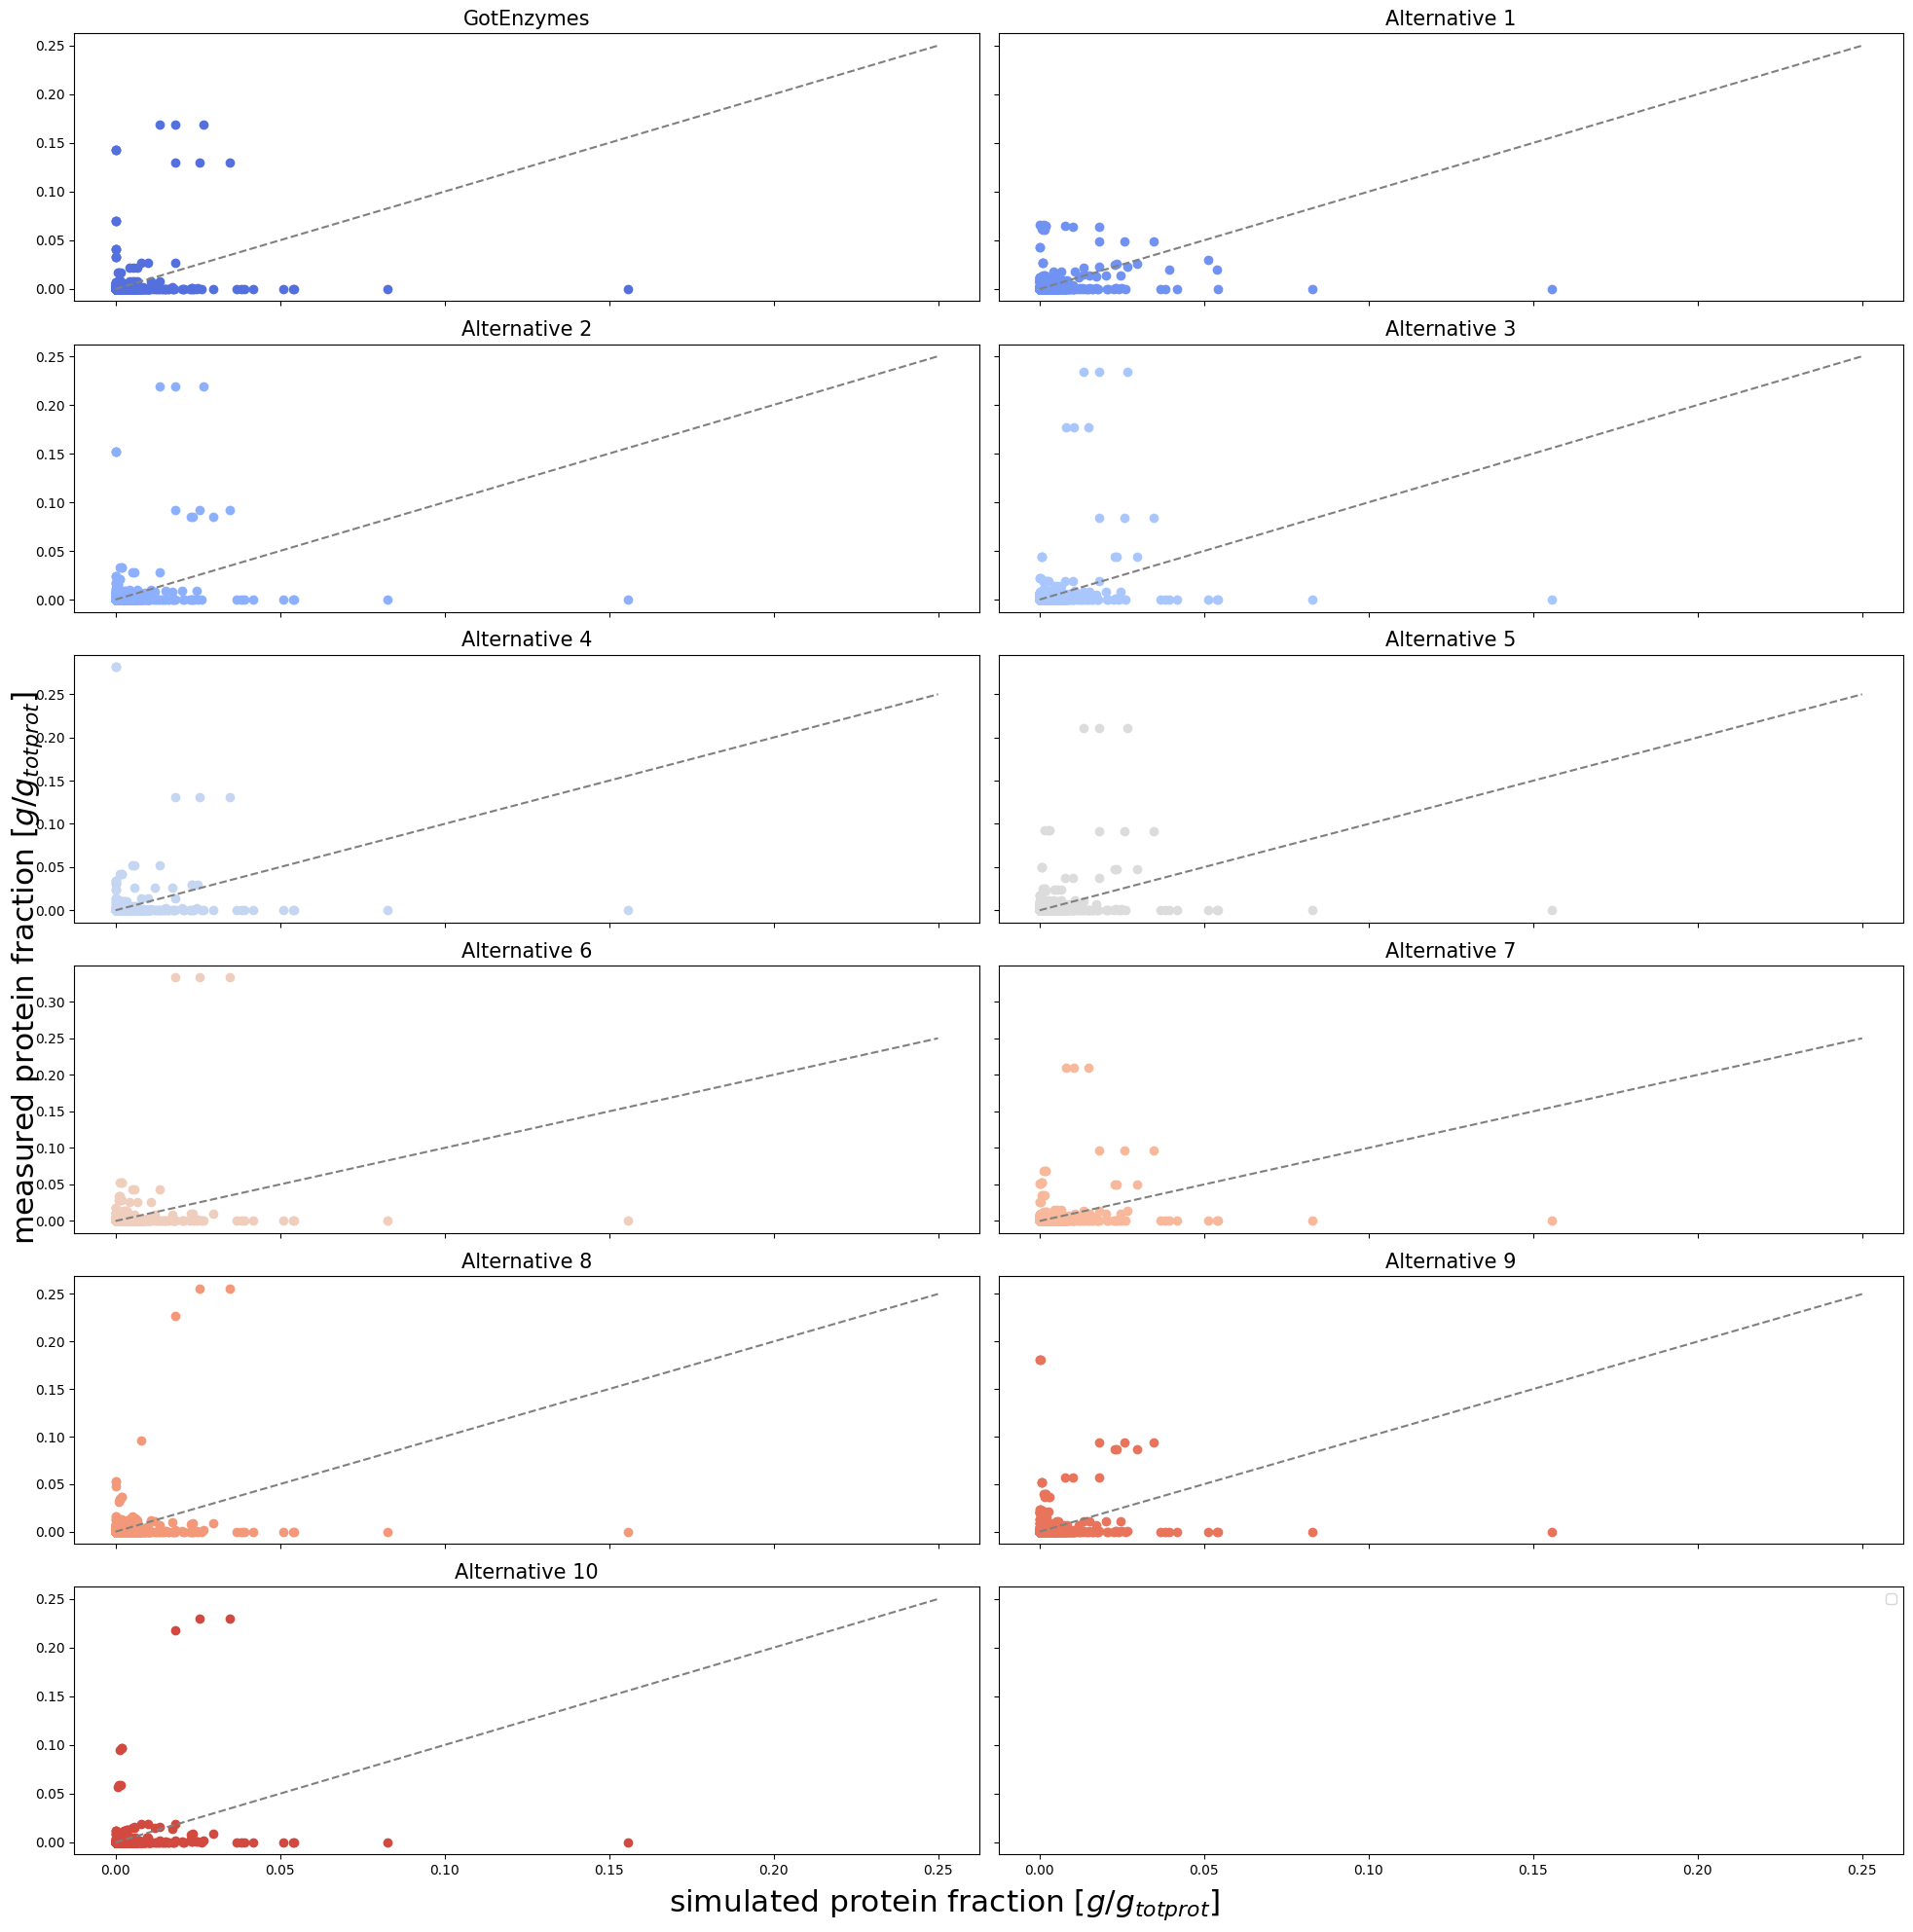

In [29]:
models = proteomics_results.keys()
model_colors = sns.color_palette("coolwarm", n_colors=len(models))
cmap = dict(zip(models, model_colors))
fontsize=15

fig, axs = plt.subplots(nrows = int(np.ceil(len(models)/2)), ncols = 2, sharey='row', sharex='col', figsize = (20,20))
axs = axs.flatten()

for ax, col_name, label in zip(axs,col_names, models):
    ax.plot([0,0.25], [0,0.25], linestyle = 'dashed', color='grey')
    ax.scatter(all_proteins_long['fraction'],all_proteins_long[col_name], color = cmap[label])
    ax.set_title(label, fontsize = fontsize)
    

# Remove any unused subplots
for j in range(len(models)+1, len(axs)):
    fig.delaxes(axs[j])

fig.supxlabel(r'simulated protein fraction [$g/g_{totprot}$]', fontsize = fontsize*1.5)
fig.supylabel(r'measured protein fraction [$g/g_{totprot}$]', fontsize = fontsize*1.5)
plt.legend()

plt.tight_layout()
plt.show()

### 4.3 enzyme concentration distributions

In [30]:
def create_joyplot(input_df,col_to_plot, col_to_hue,label_names: list[str], title,
                  result_fig_file:str=None):    
    # Set up the seaborn theme
    input_df['log'] = np.log10(input_df[col_to_plot])
    sns.set_theme(style="whitegrid")
    g = sns.FacetGrid(input_df, row=col_to_hue, hue=col_to_hue, aspect=15, height=0.6, palette="coolwarm")

    # Add KDE plots to the grid
    g.map(sns.kdeplot, 'log', fill=True, alpha=0.7, linewidth=1.5)

    # Add a white line to separate KDE plots for better visibility
    g.map(sns.kdeplot, 'log', color="white", linewidth=1)

    # Set y-labels using the provided label names
    for ax, label in zip(g.axes.flat, label_names):
        ax.text(0, 0, label, ha="right", va="bottom", fontsize=12, color="black", transform=ax.transAxes)

    # Format x-axis to display scientific notation (10^x)
    for ax in g.axes.flat:
        ticks = ax.get_xticks()
        ax.set_xticklabels([f"1e{round(i)}" for i in ticks], fontsize=10)

    # Customize appearance
    g.fig.subplots_adjust(hspace=-0.6)
    g.set_titles("")
    g.set(yticks=[], ylabel="")
    g.despine(bottom=True, left=True)

    # Add a title and x-axis label
#     plt.xscale('log')
    plt.title(title, fontsize=14, pad=20)
    plt.xlabel(r"Normalized peptide concentration [$g_{protein}/\sum g_{protein}$]", fontsize=12)

    # Tight layout for better spacing
    plt.tight_layout()

    # Save the plot
    if result_fig_file is not None:
        plt.savefig(result_fig_file, dpi=300)
    else:
        plt.show()

In [32]:
cols = ['fraction', 'normalized_fraction']+[f'normalized_fraction_{i}' for i in range(1,NUM_ALT_MODELS +1)]
all_proteins_per_configs = all_proteins_long.melt(id_vars=['enzyme_id', 'method'], 
                                                  value_vars=cols,
                                                  var_name='model', 
                                                  value_name='frac')
all_proteins_per_configs

,enzyme_id,method,model,frac
0,Q46856,Batch,fraction,0.000778
1,P08331,Batch,fraction,0.000099
2,P31119,Batch,fraction,0.000005
3,P39359,Batch,fraction,0.000019
4,P75682,Batch,fraction,0.000032
...,...,...,...,...
25843,P09053,mu_5,normalized_fraction_10,0.000000
25844,P31434,mu_5,normalized_fraction_10,0.000000
25845,P00944,mu_5,normalized_fraction_10,0.000000
25846,P0AGF4,mu_5,normalized_fraction_10,0.000000


/home/samiralvdb/Software/anaconda3/envs/PAModelpy/lib/python3.9/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/samiralvdb/Software/anaconda3/envs/PAModelpy/lib/python3.9/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/tmp/ipykernel_459680/3145168015.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"1e{round(i)}" for i in ticks], fontsize=10)
/tmp/ipykernel_459680/3145168015.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"1e{round(i)}" for i in ticks], fontsize=10)
/tmp/ipykernel_459680/3145168015.py:21: UserWarning: set_ticklabels() should only be used with a fixe

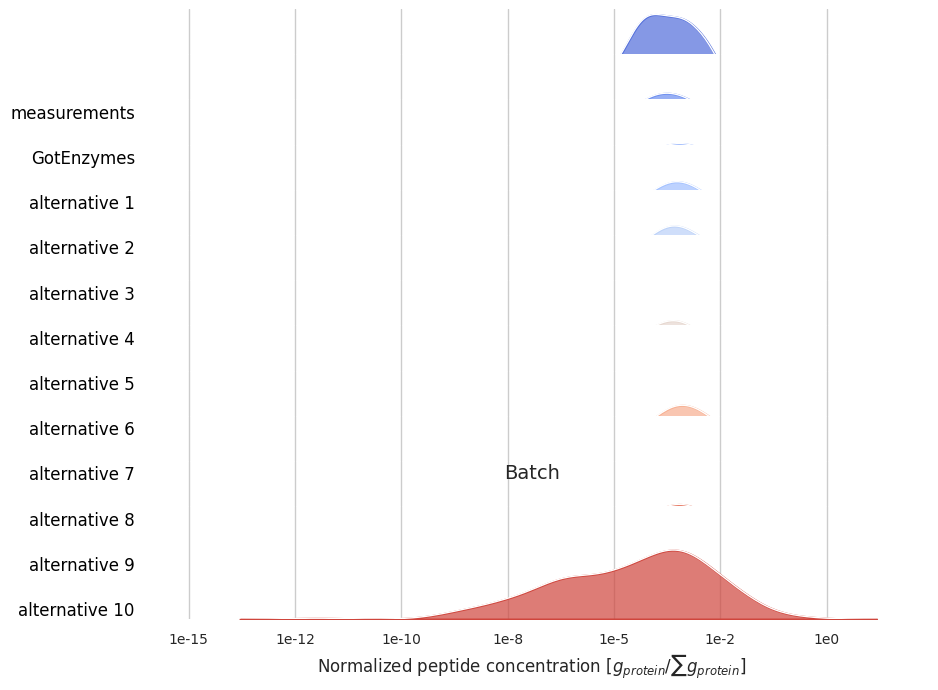

      enzyme_id method                   model      frac       log
211      P0ABK5  Batch                fraction  0.054194 -1.266050
2431     P0A9B2  Batch     normalized_fraction  0.130046 -0.885902
2439     P0A6P9  Batch     normalized_fraction  0.168634 -0.773056
2442     P78055  Batch     normalized_fraction  0.142639 -0.845763
2869     P00944  Batch     normalized_fraction  0.070271 -1.153223
4408     P0A825  Batch   normalized_fraction_1  0.064220 -1.192329
4735     P0AB80  Batch   normalized_fraction_1  0.064997 -1.187108
4916     P15640  Batch   normalized_fraction_1  0.061317 -1.212420
6739     P0A9B2  Batch   normalized_fraction_2  0.091860 -1.036874
6744     P77399  Batch   normalized_fraction_2  0.152214 -0.817546
6747     P0A6P9  Batch   normalized_fraction_2  0.219082 -0.659394
7048     P0A799  Batch   normalized_fraction_2  0.084768 -1.071770
8893     P0A9B2  Batch   normalized_fraction_3  0.084426 -1.073523
8901     P0A6P9  Batch   normalized_fraction_3  0.234225 -0.63

/home/samiralvdb/Software/anaconda3/envs/PAModelpy/lib/python3.9/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/samiralvdb/Software/anaconda3/envs/PAModelpy/lib/python3.9/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/tmp/ipykernel_459680/3145168015.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"1e{round(i)}" for i in ticks], fontsize=10)
/tmp/ipykernel_459680/3145168015.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"1e{round(i)}" for i in ticks], fontsize=10)
/tmp/ipykernel_459680/3145168015.py:21: UserWarning: set_ticklabels() should only be used with a fixe

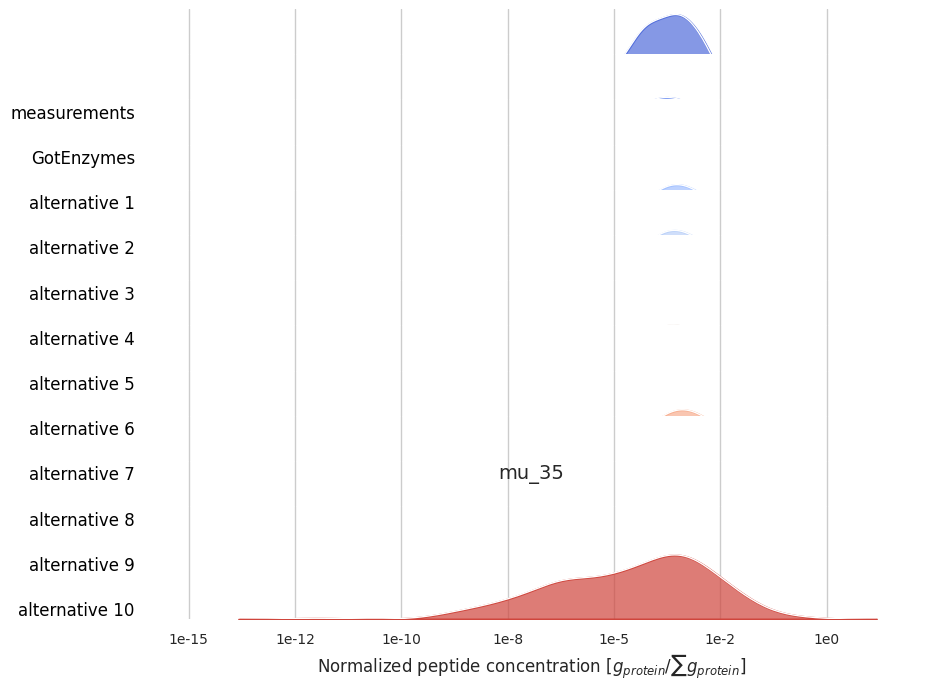

      enzyme_id method                   model      frac       log
1141     P0A9G6  mu_35                fraction  0.155697 -0.807720
3157     P0A6P9  mu_35     normalized_fraction  0.168634 -0.773056
7465     P0A6P9  mu_35   normalized_fraction_2  0.219082 -0.659394
9619     P0A6P9  mu_35   normalized_fraction_3  0.234225 -0.630367
9630     P0AB71  mu_35   normalized_fraction_3  0.176565 -0.753096
11770    P77399  mu_35   normalized_fraction_4  0.281654 -0.550285
13927    P0A6P9  mu_35   normalized_fraction_5  0.211098 -0.675516
16073    P0A9B2  mu_35   normalized_fraction_6  0.333021 -0.477528
18246    P0AB71  mu_35   normalized_fraction_7  0.209740 -0.678319
20381    P0A9B2  mu_35   normalized_fraction_8  0.227133 -0.643719
22540    P77399  mu_35   normalized_fraction_9  0.180686 -0.743076
24689    P0A9B2  mu_35  normalized_fraction_10  0.217491 -0.662558


/home/samiralvdb/Software/anaconda3/envs/PAModelpy/lib/python3.9/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/samiralvdb/Software/anaconda3/envs/PAModelpy/lib/python3.9/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/tmp/ipykernel_459680/3145168015.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"1e{round(i)}" for i in ticks], fontsize=10)
/tmp/ipykernel_459680/3145168015.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"1e{round(i)}" for i in ticks], fontsize=10)
/tmp/ipykernel_459680/3145168015.py:21: UserWarning: set_ticklabels() should only be used with a fixe

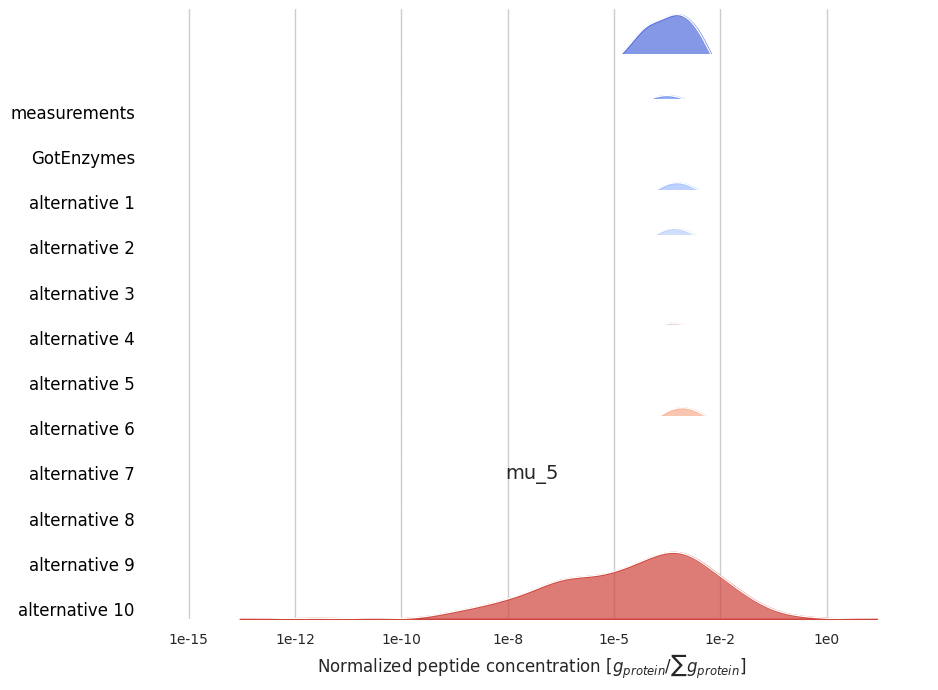

      enzyme_id method                   model      frac       log
1859     P0A9G6   mu_5                fraction  0.082777 -1.082088
3867     P0A9B2   mu_5     normalized_fraction  0.130046 -0.885902
3875     P0A6P9   mu_5     normalized_fraction  0.168634 -0.773056
3878     P78055   mu_5     normalized_fraction  0.142639 -0.845763
8175     P0A9B2   mu_5   normalized_fraction_2  0.091860 -1.036874
8180     P77399   mu_5   normalized_fraction_2  0.152214 -0.817546
8183     P0A6P9   mu_5   normalized_fraction_2  0.219082 -0.659394
8484     P0A799   mu_5   normalized_fraction_2  0.084768 -1.071770
10329    P0A9B2   mu_5   normalized_fraction_3  0.084426 -1.073523
10337    P0A6P9   mu_5   normalized_fraction_3  0.234225 -0.630367
10348    P0AB71   mu_5   normalized_fraction_3  0.176565 -0.753096
12483    P0A9B2   mu_5   normalized_fraction_4  0.130907 -0.883038
12488    P77399   mu_5   normalized_fraction_4  0.281652 -0.550287
14637    P0A9B2   mu_5   normalized_fraction_5  0.091415 -1.03

In [33]:
for experiment, peptide_df in all_proteins_per_configs.groupby('method'):
    create_joyplot(input_df=peptide_df,
                   col_to_plot = 'frac', 
                   col_to_hue = 'model',
                   label_names=['measurements', 'GotEnzymes'] + [f'alternative {i}' for i in range(1,NUM_ALT_MODELS+1)],
                   title = experiment)
    max_expression_exp = peptide_df.frac[peptide_df.model == 'fraction'].max()
    print(peptide_df[peptide_df.frac >=max_expression_exp])

/home/samiralvdb/Software/anaconda3/envs/PAModelpy/lib/python3.9/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/samiralvdb/Software/anaconda3/envs/PAModelpy/lib/python3.9/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/tmp/ipykernel_459680/3145168015.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"1e{round(i)}" for i in ticks], fontsize=10)
/tmp/ipykernel_459680/3145168015.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"1e{round(i)}" for i in ticks], fontsize=10)
/tmp/ipykernel_459680/3145168015.py:21: UserWarning: set_ticklabels() should only be used with a fixe

      enzyme_id method                   model      frac       log
3875     P0A6P9   mu_5     normalized_fraction  0.168634 -0.773056
8183     P0A6P9   mu_5   normalized_fraction_2  0.219082 -0.659394
10337    P0A6P9   mu_5   normalized_fraction_3  0.234225 -0.630367
10348    P0AB71   mu_5   normalized_fraction_3  0.176565 -0.753096
12488    P77399   mu_5   normalized_fraction_4  0.281652 -0.550287
14645    P0A6P9   mu_5   normalized_fraction_5  0.211098 -0.675516
16791    P0A9B2   mu_5   normalized_fraction_6  0.333021 -0.477528
18964    P0AB71   mu_5   normalized_fraction_7  0.209740 -0.678319
21099    P0A9B2   mu_5   normalized_fraction_8  0.255976 -0.591801
23258    P77399   mu_5   normalized_fraction_9  0.180686 -0.743076
25407    P0A9B2   mu_5  normalized_fraction_10  0.229670 -0.638896


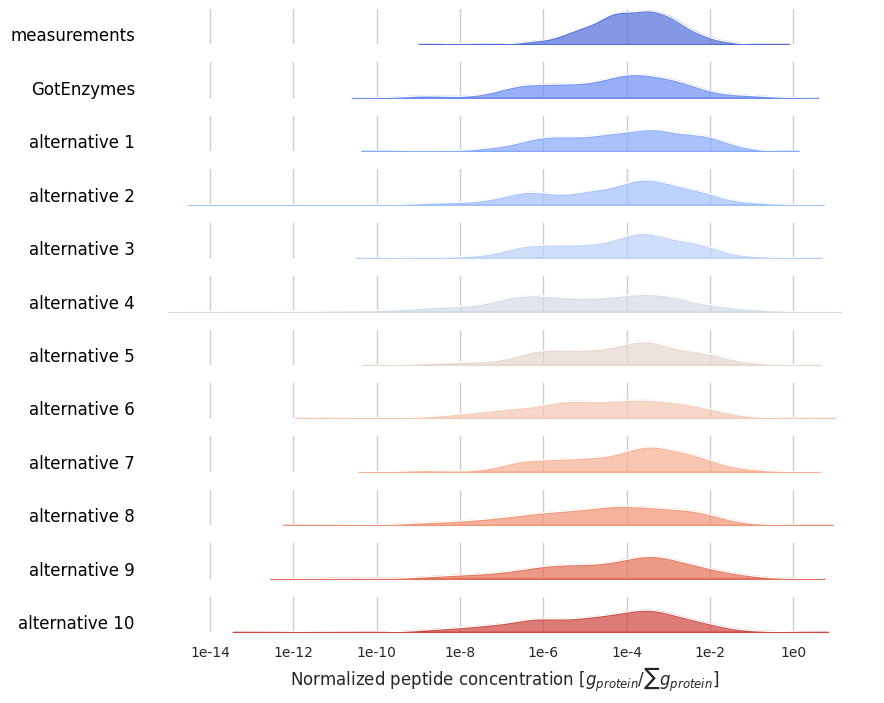

In [35]:
create_joyplot(input_df=all_proteins_per_configs,
                   col_to_plot = 'frac', 
                   col_to_hue = 'model',
                   label_names=['measurements', 'GotEnzymes'] + [f'alternative {i}' for i in range(1,NUM_ALT_MODELS+1)],
                   title = '',
               result_fig_file = os.path.join('Results', '3_analysis', 'protein_concentration_joyplot.png')
              )
max_expression_exp = all_proteins_per_configs.frac[all_proteins_per_configs.model == 'fraction'].max()
print(peptide_df[peptide_df.frac >=max_expression_exp])

#### Boxplots

In [36]:
difference = {}
for col in cols[1:]:
    difference[col] = [conc- all_proteins_long.fraction.to_list()[i] 
                       for i, conc in enumerate(all_proteins_long[col].to_list())]
difference_df = pd.DataFrame(difference).dropna()
difference_df = difference_df.melt(value_vars=cols[1:],var_name='model', value_name='difference')
difference_df

,model,difference
0,normalized_fraction,-7.776417e-04
1,normalized_fraction,-9.910617e-05
2,normalized_fraction,-4.668012e-06
3,normalized_fraction,-1.941502e-05
4,normalized_fraction,-3.169916e-05
...,...,...
23689,normalized_fraction_10,-2.799585e-04
23690,normalized_fraction_10,-3.856239e-07
23691,normalized_fraction_10,-1.600990e-04
23692,normalized_fraction_10,-3.488478e-07


/tmp/ipykernel_459680/2406405858.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=fontsize)


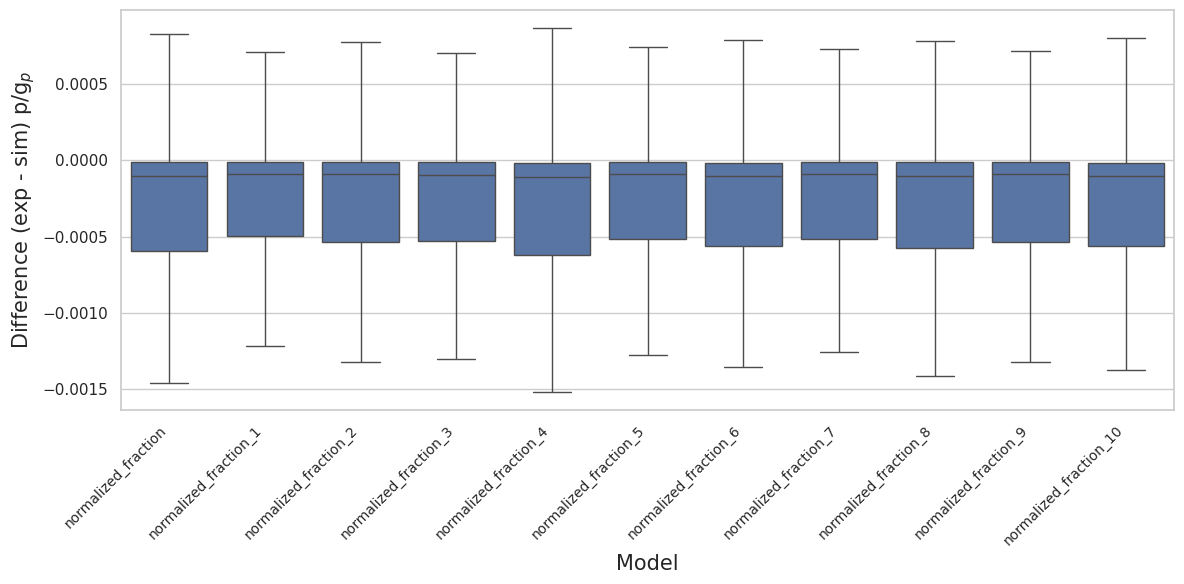

In [37]:
fontsize = 10
fig, ax = plt.subplots(figsize=(12, 6))

# Boxplot or Violin Plot
sns.boxplot(x='model', y='difference', data=difference_df, ax=ax, showfliers=False)

# Adjust y-axis to focus on bulk data and add space for annotations
# ax.set_ylim([difference_df['difference'].quantile(0.05), difference_df['difference'].quantile(0.95)+3])

# Set labels and title
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=fontsize)
ax.set_xlabel('Model', fontsize=fontsize * 1.5)
ax.set_ylabel(r'Difference (exp - sim) p/$\text{g}_{p}$', fontsize=fontsize * 1.5)

plt.tight_layout()
plt.show()

## 5 COG analysis

In [43]:
#match the cog classes to the protein concentrations
total_proteome_df_cog = all_proteins_long.merge(uniprot_df[['Entry', 'b_number']], 
                                                left_on = 'enzyme_id', 
                                                right_on = 'Entry')
total_proteome_df_cog = total_proteome_df_cog.merge(proteome_df_cog[['COG Name']], 
                                                left_on = 'b_number', 
                                                right_index=True)
#make sure there is only one COG associated with each row
total_proteome_df_cog['COG Name'] = total_proteome_df_cog['COG Name'].str.split(",")
total_proteome_df_cog = total_proteome_df_cog.explode('COG Name').reset_index(drop=True)
total_proteome_df_cog

,method,enzyme_id,normalized_fraction,normalized_fraction_1,normalized_fraction_2,normalized_fraction_3,normalized_fraction_4,normalized_fraction_5,normalized_fraction_6,normalized_fraction_7,normalized_fraction_8,normalized_fraction_9,normalized_fraction_10,experiment,fraction,Entry,b_number,COG Name
0,Batch,Q46856,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Batch,0.000778,Q46856,b3011,Energy production and conversion
1,mu_35,Q46856,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,mu_35,0.000302,Q46856,b3011,Energy production and conversion
2,mu_5,Q46856,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,mu_5,0.000506,Q46856,b3011,Energy production and conversion
3,Batch,P08331,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Batch,0.000099,P08331,b4213,Nucleotide transport and metabolism
4,mu_35,P08331,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,mu_35,0.000238,P08331,b4213,Nucleotide transport and metabolism
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2275,Batch,P33025,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Batch,0.000005,P33025,b2165,transport and catabolism
2276,mu_35,P33025,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,mu_35,0.000116,P33025,b2165,Secondary metabolites biosynthesis
2277,mu_35,P33025,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,mu_35,0.000116,P33025,b2165,transport and catabolism
2278,mu_5,P33025,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,mu_5,0.000046,P33025,b2165,Secondary metabolites biosynthesis


### 5.1 Plot abundances per COG

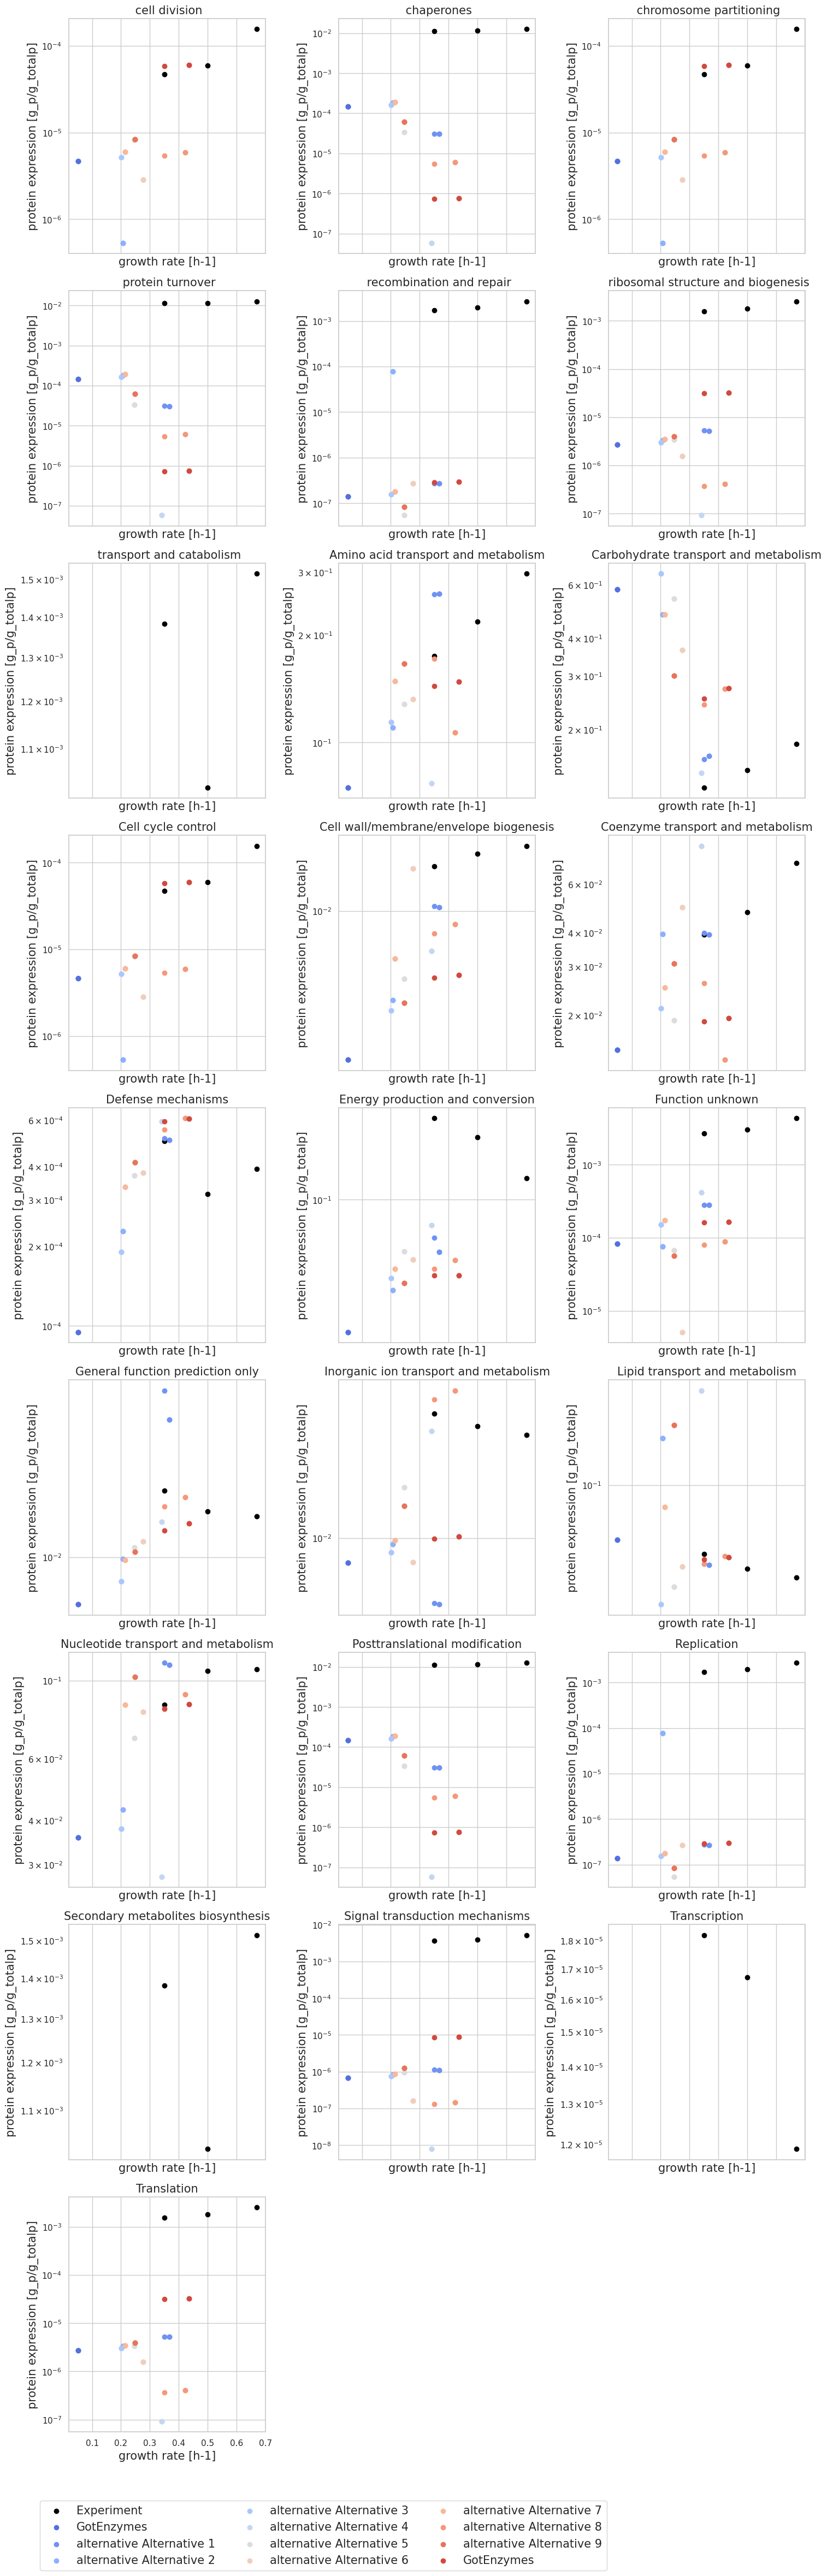

In [45]:
total_proteome_df_grouped_cog = total_proteome_df_cog.groupby('COG Name')
col2label = {column: label for column, label in zip(
    cols, 
    ['Experiment', 'GotEnzymes']+[f'Alternative {i}' for i in range(1,NUM_ALT_MODELS+1)]
)
            }

fontsize = 15

model_colors = sns.color_palette("coolwarm", n_colors=len(col2label)-1)
cmap = dict(zip([name for name in cols if name != 'fraction'], model_colors))

n_rows = int(np.ceil(len(total_proteome_df_grouped_cog) / 3))
fig, axs = plt.subplots(n_rows, 3, figsize=(15, 5 * n_rows), sharex=True, sharey=False)

axs = axs.flatten()
i=0

for cog, prot_conc_df in total_proteome_df_grouped_cog:
    ax = axs[i]
    summary = prot_conc_df.groupby(['method'])[cols].sum()
    for col in cols:
        if col == 'fraction': 
            color = 'black'
            growth_rates = {'Batch':0.67,'mu_5':0.5, 'mu_35':0.35}
            label = col2label[col]
        else: 
            color = cmap[col]
            label = col2label[col]
            growth_rates = proteomics_results[label].drop_duplicates(['method', 'growth_rate']).set_index('method').to_dict()['growth_rate']
            if len(col.split('_')[-1]) == 1: label = 'alternative '+col2label[col]
            else: label = 'GotEnzymes'
        ax.scatter([growth_rates[method] for method in summary.index], summary[col], color= color, label = label)
        ax.set_title(cog, fontsize = fontsize)
        ax.set_xlabel('growth rate [h-1]', fontsize = fontsize)
        ax.set_ylabel('protein expression [g_p/g_totalp]', fontsize = fontsize)
        ax.set_yscale('log')
    i+=1

# Remove any unused subplots
for j in range(i, len(axs)):
    fig.delaxes(axs[j])
    
box = ax.get_position()
ax.set_position([box.x0, box.y0 + box.height * 0.1,
                 box.width, box.height * 0.9])
        
handles, labels = ax.get_legend_handles_labels()    
fig.legend(handles, labels, loc = 'lower center', bbox_to_anchor=(0.4, -0.05),ncols = 3, fontsize= fontsize)

    
plt.tight_layout()

## Adding protein concentrations as constraints

In [55]:
def constrain_pam_with_proteomics_measurements(pam, 
                                               measured_protein_df: pd.DataFrame):
    for i, row in measured_protein_df.iterrows():
        pam.enzyme_variables.get_by_id(row.enzyme_id).concentration = row.concentration
    return pam

def save_simulation_results(result_df: pd.DataFrame, 
                            all_results: list)-> list:
    for enzyme, conc in result_df.items():
        all_results.append({
            "Model": "Proteomics-Constrained",
            "Method": method,
            "Growth Rate": mu,
            "Enzyme": enzyme,
            "Concentration": conc
        })
    return all_results

In [56]:
growth_rates = [0.67, 0.5, 0.35]
pam =  set_up_pam(ORI_PAM_KCAT_FILE, ECOLI_MODEL_FILE_PATH, sensitivity=False)
enzymes = [enz.id for enz in pam.enzyme_variables if enz._model is not None]
proteomic_constrained_results = []


for method, mu in zip(['Batch', 'mu_5', 'mu_35'], growth_rates):
    #get the measured concentration in mmol/gcdw
    exp_conc = proteome_glc_mmol[
        ['enzyme_id', method]
    ].rename(
        {method: 'concentration'},
        axis=1
    )
    
    pam_constrained = constrain_pam_with_proteomics_measurements(pam.copy(copy_with_pickle = True), 
                                               exp_conc)
    
    gotenzymes ={'GotEnzymes': get_results_from_simulations_fixed_mu(
        pamodel=pam_constrained,
        growth_rates = [mu],
        proteins_to_save = enzymes,
        method_ids = [method]
    )['proteins']}
    
    proteomic_constrained_results = save_simulation_results(gotenzymes,
                                                           proteomic_constrained_results)

    for file, label in zip(BEST_INDIV_RESULT_FILES,
                           [f'Alternative {i}' for i in range(1,len(PAM_KCAT_FILES)+1)]
                          ):
        print('\n')
        print(label)
        model = create_pamodel_from_diagnostics_file(
            file,
            pam_constrained.copy(copy_with_pickle=True)
        )
        
        enzymes = [enz.id for enz in model.enzyme_variables if enz._model is not None]
        alternative = {label: get_results_from_simulations_fixed_mu(pamodel=model,
                                                                          growth_rates = [mu],
                                                                          proteins_to_save = enzymes,
                                                                          method_ids = [method]
                                                                         )['proteins']}
        proteomic_constrained_results = save_simulation_results(alternative,
                                                           proteomic_constrained_results)
    
# Convert results to a dataframe
results_df = pd.DataFrame(all_results)

# Display the first few rows
print(results_df.head())

# Optionally, save to a CSV file
results_df.to_csv("simulation_results.csv", index=False)
    

No enzyme information found for reaction: QUINDHyi
No enzyme information found for reaction: QUINDH
Setting up the proteome allocation model iML1515

Add total condition-dependent protein constraint
	Total protein concentration: 0.258 g/gDW

Add active protein sector

Add the following protein sector: TranslationalProteinSector

Add the following protein sector: UnusedEnzymeSector

Done with setting up the proteome allocation model iML1515



KeyError: 'P31119_P0A6A8'